In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt #data visualization
import seaborn as sns
from sklearn.model_selection import train_test_split # Split data to train and test data(after merging in this case)
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix 
import warnings
warnings.filterwarnings('ignore')


# import libraries from tensorflow
from tensorflow import keras
import tensorflow as tf
from keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout,Input, BatchNormalization, LeakyReLU, ReLU
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.initializers import HeUniform

In [2]:
pd.set_option('display.max_rows', None) 
df = pd.read_excel("SMILES_TrainingDataset_July2_172_Plus_16LY_Fixed.xlsx")

df.head()

,Acid (name),Acid (SMILES),Acid (equiv.),Amine (name),Amine (SMILES),Amine (equiv.),Activator (name),Activator (SMILES),Activator (equiv.),Base (name),Base (SMILES),Base (equiv.),Solvent,Solvent (SMILES),Global Conc (M),Temp (C),Time (h),Reaction_Yield,References
0,N-Boc-L-leucine,CC(C)C[C@@H](C(O)=O)NC(OC(C)(C)C)=O,1.0,Piperidine,N1CCCCC1,1.1,EDCI,CN(C)CCCN=C=NCC,1.1,Piperidine,N1CCCCC1,1.0,DCM,ClCCl,0.60,25,2.0,96,https://doi.org/10.1039/C2CC31735D
1,N-Boc-L-leucine,CC(C)C[C@@H](C(O)=O)NC(OC(C)(C)C)=O,1.0,Piperidine,N1CCCCC1,1.1,DCC,C1(CCCCC1)N=C=NC2CCCCC2,1.5,Piperidine,N1CCCCC1,1.0,DCM,ClCCl,0.25,25,1.5,88,https://doi.org/10.1021/acsomega.0c06053
2,N-Boc-L-leucine,CC(C)C[C@@H](C(O)=O)NC(OC(C)(C)C)=O,1.0,Piperidine,N1CCCCC1,1.1,HBTU,CN(C)/C(N(C)C)=[O+]\N1N=NC2=CC=CC=C21.F[P-](F)...,1.5,DIPEA,CC(C)N(CC)C(C)C,2.0,DMF,O=CN(C)C,0.50,25,1.0,96,10.1021/jo0349375
3,Boc-L-tert-leucine,CC(C)(C)[C@@H](C(O)=O)NC(OC(C)(C)C)=O,1.0,Piperidine,N1CCCCC1,1.1,HBTU,CN(C)/C(N(C)C)=[O+]\N1N=NC2=CC=CC=C21.F[P-](F)...,1.5,DIPEA,CC(C)N(CC)C(C)C,2.0,DMF,O=CN(C)C,0.50,25,16.0,90,https://doi.org/10.1002/ejoc.202100355
4,Boc-L-tert-leucine,CC(C)(C)[C@@H](C(O)=O)NC(OC(C)(C)C)=O,1.0,Piperidine,N1CCCCC1,1.1,HBTU,CN(C)/C(N(C)C)=[O+]\N1N=NC2=CC=CC=C21.F[P-](F)...,1.5,DIPEA,CC(C)N(CC)C(C)C,2.0,DMF,O=CN(C)C,0.50,25,16.0,86,https://doi.org/10.1002/chem.201002202


In [3]:
#dropped Additive for trial
df = df.drop(['Acid (name)','Amine (name)','Activator (name)','Base (name)','Solvent','References'], axis=1)
df.head(1)

,Acid (SMILES),Acid (equiv.),Amine (SMILES),Amine (equiv.),Activator (SMILES),Activator (equiv.),Base (SMILES),Base (equiv.),Solvent (SMILES),Global Conc (M),Temp (C),Time (h),Reaction_Yield
0,CC(C)C[C@@H](C(O)=O)NC(OC(C)(C)C)=O,1.0,N1CCCCC1,1.1,CN(C)CCCN=C=NCC,1.1,N1CCCCC1,1.0,ClCCl,0.6,25,2.0,96


In [ ]:
# #dropped Additive for trial
# df = df.drop(['References'], axis=1)
# df.head(1)

In [4]:
df.isnull().sum()

Acid (SMILES)         0
Acid (equiv.)         0
Amine (SMILES)        0
Amine (equiv.)        0
Activator (SMILES)    0
Activator (equiv.)    0
Base (SMILES)         0
Base (equiv.)         0
Solvent (SMILES)      0
Global Conc (M)       0
Temp (C)              0
Time (h)              0
Reaction_Yield        0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Acid (SMILES)       200 non-null    object 
 1   Acid (equiv.)       200 non-null    float64
 2   Amine (SMILES)      200 non-null    object 
 3   Amine (equiv.)      200 non-null    float64
 4   Activator (SMILES)  200 non-null    object 
 5   Activator (equiv.)  200 non-null    float64
 6   Base (SMILES)       200 non-null    object 
 7   Base (equiv.)       200 non-null    float64
 8   Solvent (SMILES)    200 non-null    object 
 9   Global Conc (M)     200 non-null    float64
 10  Temp (C)            200 non-null    int64  
 11  Time (h)            200 non-null    float64
 12  Reaction_Yield      200 non-null    int64  
dtypes: float64(6), int64(2), object(5)
memory usage: 20.4+ KB


In [21]:
# #Data Imputation
# from sklearn.impute import SimpleImputer

# # Columns with missing values
# missing_columns = ['Activator (equiv.)', 'Time (h)']

# # 1. Imputation for numerical features (using mean or median)
# numerical_columns = ['Acid (equiv.)', 'Amine (equiv.)', 'Activator (equiv.)', 'Base (equiv.)', 
#                      'Global Conc (M)', 'Temp (C)', 'Time (h)']

# # Create a SimpleImputer for numerical columns (using 'mean' strategy)
# imputer_num = SimpleImputer(strategy='mean')

# # Apply the imputer to numerical columns
# df[numerical_columns] = imputer_num.fit_transform(df[numerical_columns])

In [11]:
# df.isnull().sum()

In [6]:
# Splitting the dataset into features (X) and target variable (y)
X_train = df.drop(columns=['Reaction_Yield'])
y_train = df['Reaction_Yield']

# Splitting into training and testing datasets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Display the first few rows of the preprocessed data
X_train.shape

(200, 12)

### Loading test data

In [7]:
# actual test data
df_test = pd.read_excel("SMILES_TestingDataset_July3_Final.xlsx") #June 29 previous test reactions + low-yield test reactions based on reviewer's comments
# df_test = pd.read_excel("SMILES_DrugMoleculeTesting_WithConstantTime_PredYield_Jan20_2026.xlsx")
# df_test.drop('References',axis=1,inplace=True)
df_test.drop(['Acid (name)','Amine (name)','Activator (name)','Base (name)','Solvent','References'], axis=1,inplace=True)
# df_test.drop(['Acid (name)','Amine (name)','Activator (name)','Base (name)','Solvent','References', 'Predicted_Yield_Before', 'Predicted_Yield_July4'], axis=1,inplace=True)
# Splitting the test dataset into features (X) and target variable (y)
X_test = df_test.drop(columns=['Reaction_Yield'])
y_test = df_test['Reaction_Yield']

In [8]:
df_test.isnull().sum()

Acid (SMILES)         0
Acid (equiv.)         0
Amine (SMILES)        0
Amine (equiv.)        0
Activator (SMILES)    0
Activator (equiv.)    0
Base (SMILES)         0
Base (equiv.)         0
Solvent (SMILES)      0
Global Conc (M)       0
Temp (C)              0
Time (h)              0
Reaction_Yield        0
dtype: int64

In [9]:
X_test.shape

(30, 12)

### Replacing SMILES in training and testing data with acceptable format as some format do not match with RDKit

In [10]:
import numpy as np

# 1) THF:Water → C1CCOC1 + OO
df.loc[96, 'Solvent (SMILES)'] = 'C1CCOC1.OO'

# 2) trifluoroacetic acid
df.loc[148, 'Acid (SMILES)'] = 'O=C(O)C(F)(F)F'

# 3) DCM/DMF (1:1) → ClCCl + CN(C)C=O
df.loc[29, 'Solvent (SMILES)'] = 'ClCCl.CN(C)C=O'

# 4) row 73 is a complicated Ir/Co organometallic  
#    we’ll just clear all five SMILES columns so featurizer returns a zero‐vector
df.loc[73, ['Acid (SMILES)',
            'Amine (SMILES)',
            'Activator (SMILES)',
            'Base (SMILES)',
            'Solvent (SMILES)']] = [np.nan]*5
# 5) row 4 of test dataset
df_test.loc[4, 'Solvent (SMILES)'] = 'C1CCOC1.OO'

# Now you can safely re-run:
# fp_train = np.vstack(df.apply(featurize_reaction, axis=1).values)
# fp_test  = np.vstack(df_test.apply(featurize_reaction, axis=1).values)


### Converting SMILES into 1024‐bit ECFP4 fingerprint ( Morgan Fingerprints ) and applying to dataframes

In [11]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray
import numpy as np

def featurize_reaction(row):
    # 1) load raw SMILES, may include 'Nil' or trailing dots
    raw = {
        'acid':      row['Acid (SMILES)'],
        'amine':     row['Amine (SMILES)'],
        'activator': row['Activator (SMILES)'],
        'base':      row['Base (SMILES)'],
        'solvent':   row['Solvent (SMILES)']
    }
    mols = []
    for name, smi in raw.items():
        if not isinstance(smi, str):
            continue
        smi_clean = smi.strip().rstrip('.')  # remove trailing dots
        if smi_clean.lower() in ('', 'nil'):
            continue
        
        m = Chem.MolFromSmiles(smi_clean)
        if m is None:
            print(f"[Row {row.name}] could not parse {name} SMILES: {smi_clean}")
            continue
        
        # sanitize each fragment
        try:
            Chem.SanitizeMol(m)
        except Exception as e:
            print(f"[Row {row.name}] sanitization failed for {name}: {e}")
            continue
        
        mols.append(m)
    
    # if nothing valid, return zero fingerprint
    if not mols:
        return np.zeros((1024,), dtype=np.int8)
    
    # 2) combine fragments
    combo = mols[0]
    for m in mols[1:]:
        combo = Chem.CombineMols(combo, m)
    
    # 3) sanitize the full multi‐fragment mol (builds RingInfo)
    try:
        Chem.SanitizeMol(combo)
    except Exception:
        # if it still won’t sanitize, we’ll fallback to zero
        print(f"[Row {row.name}] failed to sanitize combined molecule; skipping.")
        return np.zeros((1024,), dtype=np.int8)
    
    # 4) compute the 1024‐bit ECFP4 fingerprint
    fp = AllChem.GetMorganFingerprintAsBitVect(combo, radius=2, nBits=1024)
    arr = np.zeros((1024,), dtype=np.int8)
    ConvertToNumpyArray(fp, arr)
    return arr

# apply to your DataFrames safely
fp_train = np.vstack(df.apply(featurize_reaction, axis=1).values)
fp_test  = np.vstack(df_test.apply(featurize_reaction, axis=1).values)


In [13]:
# ── 2. Stack numeric features + fingerprints ──────────────────────────────────
numeric_cols = [
    'Acid (equiv.)', 'Amine (equiv.)',
    'Activator (equiv.)', 'Base (equiv.)',
    'Global Conc (M)', 'Temp (C)', 'Time (h)'
]
X_train_numeric = df[numeric_cols].to_numpy()
X_test_numeric  = df_test[numeric_cols].to_numpy()

X_train = np.hstack([X_train_numeric, fp_train])
X_test  = np.hstack([X_test_numeric,  fp_test])

y_train = df['Reaction_Yield'].to_numpy()
y_test  = df_test['Reaction_Yield'].to_numpy()

In [14]:
X_train[:5]

array([[1. , 1.1, 1.1, ..., 0. , 0. , 0. ],
       [1. , 1.1, 1.5, ..., 0. , 0. , 0. ],
       [1. , 1.1, 1.5, ..., 0. , 0. , 0. ],
       [1. , 1.1, 1.5, ..., 0. , 0. , 0. ],
       [1. , 1.1, 1.5, ..., 0. , 0. , 0. ]])

## Baseline 1: (MLP + ECFP4) with loss tracking

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error
# import random

# np.random.seed(42)
# random.seed(42)
# tf.random.set_seed(42)

# import torch, numpy as np, random

# print("torch.initial_seed():", torch.initial_seed())   # returns current base seed for CPU RNG
# print("numpy random state head:", np.random.get_state()[1][:5])
# print("python random state head:", random.getstate()[1][:5])

# if torch.cuda.is_available():
#     print("cuda initial seed (device 0):", torch.cuda.initial_seed())


# Convert to tensors
Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

Xte = torch.tensor(X_test, dtype=torch.float32)
yte = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=16, shuffle=True)

# -------------------- MODEL --------------------
class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(d_in, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.layers(x)

model = MLP(X_train.shape[1])
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# -------------------- LOSS TRACKING --------------------
train_loss_per_epoch = []
test_loss_per_epoch  = []   # optional, but useful for comparison

# -------------------- TRAIN --------------------
for epoch in range(50):
    model.train()
    running = 0.0
    n = 0

    for xb, yb in train_loader:
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()

        running += loss.item() * xb.size(0)
        n += xb.size(0)

    # average train loss for this epoch
    train_epoch_loss = running / n
    train_loss_per_epoch.append(train_epoch_loss)

    # compute test loss for this epoch (optional)
    model.eval()
    with torch.no_grad():
        test_pred = model(Xte)
        test_epoch_loss = loss_fn(test_pred, yte).item()
    test_loss_per_epoch.append(test_epoch_loss)

    # (optional) print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d} | Train MSE: {train_epoch_loss:.4f} | Test MSE: {test_epoch_loss:.4f}")

# -------------------- EVAL (metrics) --------------------
model.eval()
with torch.no_grad():
    pred = model(Xte).cpu().numpy().flatten()

print("MLP R2:", r2_score(y_test, pred))
print("MLP MAE:", mean_absolute_error(y_test, pred))

# -------------------- STORE HISTORY (for later plotting across models) --------------------
loss_history1 = {
    "MLP+ECFP4": {
        "train_mse": train_loss_per_epoch,
        "test_mse": test_loss_per_epoch
    }
}


Epoch 10 | Train MSE: 196.5466 | Test MSE: 187.8169
Epoch 20 | Train MSE: 91.3281 | Test MSE: 143.5330
Epoch 30 | Train MSE: 57.5545 | Test MSE: 137.2547
Epoch 40 | Train MSE: 41.0226 | Test MSE: 128.8831
Epoch 50 | Train MSE: 41.6012 | Test MSE: 127.2756
MLP R2: 0.6814756671199675
MLP MAE: 7.80686092376709


In [35]:
# ------------------------------------------------------------
# Compute: Chi-squared test, F1 score, MAE, RMSE, R2
# Notes:
# 1) MAE/RMSE/R2 are regression metrics (use original scale by default).
# 2) F1 and Chi-squared require a *classification* target.
#    Below we convert yields into classes using a threshold.
#    You can change `threshold` to match your definition (e.g., low vs high yield).
# ------------------------------------------------------------

import numpy as np
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score,
    confusion_matrix
)
from scipy.stats import chi2_contingency

# -------------------------
# Inputs assumed available:
# y_test: np.ndarray shape (n,)
# preds_test: np.ndarray shape (n,)  (your model predictions)
# -------------------------

y_true = np.asarray(y_test).reshape(-1)
y_pred = np.asarray(pred).reshape(-1)

# -------------------------
# A) Regression metrics (original scale)
# -------------------------
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)  # RMSE
r2 = r2_score(y_true, y_pred)

print("MAE  (original scale):", mae)
print("RMSE (original scale):", rmse)
print("R2   (original scale):", r2)

# -------------------------
# B) (Optional) Regression metrics on normalized scale (0-1)
# -------------------------
scaler = MinMaxScaler()
y_true_scaled = scaler.fit_transform(y_true.reshape(-1, 1)).reshape(-1)
y_pred_scaled = scaler.transform(y_pred.reshape(-1, 1)).reshape(-1)

mae_norm = mean_absolute_error(y_true_scaled, y_pred_scaled)
rmse_norm = mean_squared_error(y_true_scaled, y_pred_scaled, squared=False)
r2_norm = r2_score(y_true_scaled, y_pred_scaled)

print("\nMAE  (normalized 0-1):", mae_norm)
print("RMSE (normalized 0-1):", rmse_norm)
print("R2   (normalized 0-1):", r2_norm)

# # -------------------------
# # C) Classification metrics: F1 + Chi-squared test
# #    Convert yields to binary classes using a threshold.
# # -------------------------
# threshold = 50.0  # CHANGE THIS to your desired cutoff (e.g., 20, 50, 80)
# y_true_cls = (y_true >= threshold).astype(int)
# y_pred_cls = (y_pred >= threshold).astype(int)

# f1 = f1_score(y_true_cls, y_pred_cls)
# print("\nF1 score (binary, threshold={}): {}".format(threshold, f1))

# # Chi-squared test on the 2x2 contingency table
# cm = confusion_matrix(y_true_cls, y_pred_cls)  # rows=true class, cols=pred class
# chi2, p_value, dof, expected = chi2_contingency(cm)

# print("\nChi-squared test (on confusion matrix):")
# print("Confusion matrix:\n", cm)
# print("chi2 =", chi2)
# print("p-value =", p_value)
# print("dof =", dof)
# print("expected counts:\n", expected)


MAE  (original scale): 7.80686092376709
RMSE (original scale): 11.28164877206687
R2   (original scale): 0.6814756671199675

MAE  (normalized 0-1): 0.10272184960756511
RMSE (normalized 0-1): 0.1484427407848602
R2   (normalized 0-1): 0.6814756937962926


In [36]:
# after training a model:
loss_history1["MLP+ECFP4"]

{'train_mse': [5122.9648046875,
  1929.062392578125,
  1024.486513671875,
  780.493330078125,
  590.2028686523438,
  455.55013549804687,
  371.3990380859375,
  289.20316040039063,
  233.40253967285156,
  196.5465936279297,
  170.63598876953125,
  146.68772338867188,
  133.71501739501954,
  124.83291137695312,
  123.29146057128906,
  113.86827606201172,
  99.36041015625,
  101.22544128417968,
  89.00691940307617,
  91.32806198120117,
  85.34144744873046,
  80.18651428222657,
  79.95368270874023,
  71.76814643859863,
  68.72459503173827,
  68.34470390319824,
  66.93842445373535,
  62.06241439819336,
  59.44871109008789,
  57.55446334838867,
  57.78246208190918,
  52.63824977874756,
  52.63767822265625,
  51.417910461425784,
  56.26335395812988,
  57.55121253967285,
  43.92898056030273,
  45.70758743286133,
  48.21594261169434,
  41.0225528717041,
  38.38296516418457,
  40.82489151000976,
  40.16636611938477,
  36.4887158203125,
  37.255119972229004,
  36.30634620666504,
  35.222488679885

## Baseline 2: Message Passing Neural Network (MPNN) with LOSS tracking added

In [27]:
# =========================
# Improved GNN baseline code (with LOSS tracking added)
# Goal: store per-epoch Train/Test loss so you can plot across models later.
# =========================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from rdkit import Chem

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import NNConv, global_mean_pool

from sklearn.metrics import r2_score, mean_absolute_error

# -------------------------
# 1) Columns
# -------------------------
SMILES_COLS = ["Acid (SMILES)", "Amine (SMILES)", "Activator (SMILES)", "Base (SMILES)", "Solvent (SMILES)"]
numeric_cols = [
    'Acid (equiv.)','Amine (equiv.)','Activator (equiv.)','Base (equiv.)',
    'Global Conc (M)','Temp (C)','Time (h)'
]

# -------------------------
# 2) SMILES cleaning
# -------------------------
def clean_smi(s):
    if s is None:
        return None
    if isinstance(s, float) and np.isnan(s):
        return None
    if not isinstance(s, str):
        s = str(s)
    s = s.strip().rstrip(".")
    if s == "" or s.lower() in {"nil", "nan", "none"}:
        return None
    return s

# -------------------------
# 3) Atom / bond features
# -------------------------
def atom_features(atom):
    z = atom.GetAtomicNum()
    degree = atom.GetDegree()
    charge = atom.GetFormalCharge()
    aromatic = 1 if atom.GetIsAromatic() else 0
    num_h = atom.GetTotalNumHs()

    hyb = atom.GetHybridization()
    hyb_map = {
        Chem.rdchem.HybridizationType.SP: 0,
        Chem.rdchem.HybridizationType.SP2: 1,
        Chem.rdchem.HybridizationType.SP3: 2,
        Chem.rdchem.HybridizationType.SP3D: 3,
        Chem.rdchem.HybridizationType.SP3D2: 4,
    }
    hyb_onehot = [0]*5
    if hyb in hyb_map:
        hyb_onehot[hyb_map[hyb]] = 1

    return [z, degree, charge, aromatic, num_h] + hyb_onehot  # dim = 10

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float32)

    edges, eattr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bt = bond.GetBondType()

        if bt == Chem.rdchem.BondType.SINGLE:
            bval = 1.0
        elif bt == Chem.rdchem.BondType.DOUBLE:
            bval = 2.0
        elif bt == Chem.rdchem.BondType.TRIPLE:
            bval = 3.0
        elif bt == Chem.rdchem.BondType.AROMATIC:
            bval = 1.5
        else:
            bval = 0.0

        arom = 1.0 if bond.GetIsAromatic() else 0.0
        conj = 1.0 if bond.GetIsConjugated() else 0.0
        ring = 1.0 if bond.IsInRing() else 0.0

        feat = [bval, arom, conj, ring]  # dim = 4
        edges.append([i, j]); eattr.append(feat)
        edges.append([j, i]); eattr.append(feat)

    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr  = torch.empty((0, 4), dtype=torch.float32)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(eattr, dtype=torch.float32)

    return x, edge_index, edge_attr

# -------------------------
# 4) Build dataset
# -------------------------
def build_dataset(df):
    data_list, bad_rows = [], 0
    for idx, row in df.iterrows():
        parts = []
        for c in SMILES_COLS:
            smi = clean_smi(row.get(c, None))
            if smi is not None:
                parts.append(smi)
        if len(parts) == 0:
            bad_rows += 1
            continue

        merged = ".".join(parts)
        g = smiles_to_graph(merged)
        if g is None:
            bad_rows += 1
            continue

        x, edge_index, edge_attr = g

        u = torch.tensor(
            row[numeric_cols].to_numpy(dtype=np.float32),
            dtype=torch.float32
        ).view(1, -1)  # (1,7)

        y = torch.tensor([float(row["Reaction_Yield"])], dtype=torch.float32)
        data_list.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, u=u, y=y))

    print(f"Built {len(data_list)} graphs; skipped {bad_rows} rows.")
    return data_list

# -------------------------
# 5) Model
# -------------------------
class MPNN(nn.Module):
    def __init__(self, node_dim=10, edge_dim=4, hidden=128, dropout=0.25):
        super().__init__()
        self.lin0 = nn.Linear(node_dim, hidden)
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden * hidden)
        )
        self.conv = NNConv(hidden, hidden, self.edge_nn, aggr="mean")
        self.dropout = nn.Dropout(dropout)
        self.u_mlp = nn.Sequential(
            nn.Linear(7, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden + hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, data):
        x = F.relu(self.lin0(data.x))
        x = F.relu(self.conv(x, data.edge_index, data.edge_attr))
        x = self.dropout(x)
        x = global_mean_pool(x, data.batch)
        u = data.u.view(-1, 7)
        u = self.u_mlp(u)
        h = torch.cat([x, u], dim=-1)
        return self.head(h)

# =========================
# 6) Training + evaluation (WITH LOSS HISTORY)
# =========================

train_graphs = build_dataset(df)
test_graphs  = build_dataset(df_test)

train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_graphs, batch_size=16, shuffle=False)

# ---- Target normalization (train stats only) ----
y_train_arr = np.array([g.y.item() for g in train_graphs], dtype=np.float32)
y_mean, y_std = float(y_train_arr.mean()), float(y_train_arr.std() + 1e-8)

for g in train_graphs:
    g.y = (g.y - y_mean) / y_std
for g in test_graphs:
    g.y_raw = g.y.clone()
    g.y = (g.y - y_mean) / y_std

model = MPNN(hidden=128, dropout=0.25)
opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=20)
loss_fn = nn.MSELoss()

# ---- LOSS TRACKING (store epoch-level averages) ----
train_loss_per_epoch = []
test_loss_per_epoch  = []

for epoch in range(300):
    # ---- Train ----
    model.train()
    total_train = 0.0
    n_train = 0

    for batch in train_loader:
        opt.zero_grad()
        pred = model(batch).view(-1)
        loss = loss_fn(pred, batch.y.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()

        total_train += loss.item() * batch.num_graphs
        n_train += batch.num_graphs

    train_mse = total_train / n_train
    train_loss_per_epoch.append(train_mse)
    sched.step(train_mse)

    # ---- Test loss (on normalized y) ----
    model.eval()
    total_test = 0.0
    n_test = 0
    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch).view(-1)
            loss = loss_fn(pred, batch.y.view(-1))
            total_test += loss.item() * batch.num_graphs
            n_test += batch.num_graphs

    test_mse = total_test / n_test
    test_loss_per_epoch.append(test_mse)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:03d} | Train MSE (norm): {train_mse:.4f} | Test MSE (norm): {test_mse:.4f}")

# ---- Evaluate on original scale ----
model.eval()
yt, yp = [], []
with torch.no_grad():
    for batch in test_loader:
        pred_norm = model(batch).view(-1).cpu().numpy()
        pred = pred_norm * y_std + y_mean
        yp.extend(pred.tolist())

        ytrue_norm = batch.y.view(-1).cpu().numpy()
        ytrue = ytrue_norm * y_std + y_mean
        yt.extend(ytrue.tolist())

print("GNN R2:", r2_score(yt, yp))
print("GNN MAE:", mean_absolute_error(yt, yp))

# ---- Store history for later plotting across models ----
# Keep a global dict and add entries like this for each model:
loss_history2 = {
    "MPNN": {
        "train_mse": train_loss_per_epoch,
        "test_mse": test_loss_per_epoch
    }
}


[22:10:18] SMILES Parse Error: syntax error while parsing: O=C(O)C1=CC=CC=C1.NC(C1=CC=CC=C1)C.2.2.ClCCl
[22:10:18] SMILES Parse Error: Failed parsing SMILES 'O=C(O)C1=CC=CC=C1.NC(C1=CC=CC=C1)C.2.2.ClCCl' for input: 'O=C(O)C1=CC=CC=C1.NC(C1=CC=CC=C1)C.2.2.ClCCl'


Built 198 graphs; skipped 2 rows.
Built 30 graphs; skipped 0 rows.
Epoch 050 | Train MSE (norm): 0.6802 | Test MSE (norm): 0.4859
Epoch 100 | Train MSE (norm): 0.4984 | Test MSE (norm): 0.8276
Epoch 150 | Train MSE (norm): 0.3908 | Test MSE (norm): 0.8932
Epoch 200 | Train MSE (norm): 0.3508 | Test MSE (norm): 0.6873
Epoch 250 | Train MSE (norm): 0.3119 | Test MSE (norm): 0.7929
Epoch 300 | Train MSE (norm): 0.2564 | Test MSE (norm): 0.7837
GNN R2: 0.05269932247251885
GNN MAE: 14.537213643391928


In [28]:
# ------------------------------------------------------------
# Compute: Chi-squared test, F1 score, MAE, RMSE, R2
# Notes:
# 1) MAE/RMSE/R2 are regression metrics (use original scale by default).
# 2) F1 and Chi-squared require a *classification* target.
#    Below we convert yields into classes using a threshold.
#    You can change `threshold` to match your definition (e.g., low vs high yield).
# ------------------------------------------------------------

import numpy as np
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score,
    confusion_matrix
)
from scipy.stats import chi2_contingency

# -------------------------
# Inputs assumed available:
# y_test: np.ndarray shape (n,)
# preds_test: np.ndarray shape (n,)  (your model predictions)
# -------------------------

y_true = np.asarray(yt).reshape(-1)
y_pred = np.asarray(yp).reshape(-1)

# -------------------------
# A) Regression metrics (original scale)
# -------------------------
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)  # RMSE
r2 = r2_score(y_true, y_pred)

print("MAE  (original scale):", mae)
print("RMSE (original scale):", rmse)
print("R2   (original scale):", r2)

# -------------------------
# B) (Optional) Regression metrics on normalized scale (0-1)
# -------------------------
scaler = MinMaxScaler()
y_true_scaled = scaler.fit_transform(y_true.reshape(-1, 1)).reshape(-1)
y_pred_scaled = scaler.transform(y_pred.reshape(-1, 1)).reshape(-1)

mae_norm = mean_absolute_error(y_true_scaled, y_pred_scaled)
rmse_norm = mean_squared_error(y_true_scaled, y_pred_scaled, squared=False)
r2_norm = r2_score(y_true_scaled, y_pred_scaled)

print("\nMAE  (normalized 0-1):", mae_norm)
print("RMSE (normalized 0-1):", rmse_norm)
print("R2   (normalized 0-1):", r2_norm)

# -------------------------
# C) Classification metrics: F1 + Chi-squared test
#    Convert yields to binary classes using a threshold.
# -------------------------
threshold = 50.0  # CHANGE THIS to your desired cutoff (e.g., 20, 50, 80)
y_true_cls = (y_true >= threshold).astype(int)
y_pred_cls = (y_pred >= threshold).astype(int)

f1 = f1_score(y_true_cls, y_pred_cls)
print("\nF1 score (binary, threshold={}): {}".format(threshold, f1))

# Chi-squared test on the 2x2 contingency table
cm = confusion_matrix(y_true_cls, y_pred_cls)  # rows=true class, cols=pred class
chi2, p_value, dof, expected = chi2_contingency(cm)

print("\nChi-squared test (on confusion matrix):")
print("Confusion matrix:\n", cm)
print("chi2 =", chi2)
print("p-value =", p_value)
print("dof =", dof)
print("expected counts:\n", expected)


MAE  (original scale): 14.537213643391928
RMSE (original scale): 19.455624885851453
R2   (original scale): 0.05269932247251885

MAE  (normalized 0-1): 0.19127913648768322
RMSE (normalized 0-1): 0.2559950771367786
R2   (normalized 0-1): 0.05269932247251918

F1 score (binary, threshold=50.0): 0.8571428571428572

Chi-squared test (on confusion matrix):
Confusion matrix:
 [[ 2  1]
 [ 6 21]]
chi2 = 0.928030303030303
p-value = 0.3353752731713191
dof = 1
expected counts:
 [[ 0.8  2.2]
 [ 7.2 19.8]]


In [39]:
loss_history2['MPNN']

{'train_mse': [3.173944176447512,
  1.571332447456591,
  1.1476891763282544,
  1.0763102059412484,
  0.9521414330511382,
  0.9598978396618005,
  0.9307955307791932,
  0.9177598327097266,
  0.9183871709939205,
  0.9169320873539857,
  0.9703331011714358,
  0.9189471671677599,
  0.8640383909447025,
  0.921128268193717,
  0.9339105498911154,
  0.9340007606178823,
  0.9793890750769413,
  0.923240308207695,
  0.9359463796471105,
  0.8812689371783324,
  0.9463932092743691,
  0.825071718355622,
  0.8798637841687058,
  0.8398289861101093,
  0.8761971008898032,
  0.8112790126993199,
  0.7991041685595657,
  0.8360979532954669,
  0.8028065604392929,
  0.8598249231023017,
  0.7696203673728789,
  0.8138263081059312,
  0.7586707948434233,
  0.8153477503795816,
  0.8420451361723621,
  0.8396162986755371,
  0.8090475219668765,
  0.7703666709589235,
  0.7056275449617945,
  0.745954983839483,
  0.825925170472174,
  0.672851091683513,
  0.7183193997903303,
  0.6693230801158481,
  0.6359950276938352,
  0.6

## Baseline 4: YieldNet with loss

In [29]:
import torch
import torch.nn as nn
from torch_geometric.nn import TransformerConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.metrics import r2_score, mean_absolute_error

# ----------- Gated Graph Transformer Layer -----------
class GatedTransformerLayer(nn.Module):
    def __init__(self, hidden_dim, heads=4, dropout=0.0):
        super().__init__()
        self.att = TransformerConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            heads=heads,
            concat=False,   # output dim stays hidden_dim
            dropout=dropout
        )
        self.gate = nn.Linear(2 * hidden_dim, hidden_dim)

    def forward(self, x, edge_index):
        h = self.att(x, edge_index)              # (N, hidden_dim)
        combined = torch.cat([x, h], dim=-1)     # (N, 2*hidden_dim)
        g = torch.sigmoid(self.gate(combined))   # (N, hidden_dim)
        return g * h + (1 - g) * x               # (N, hidden_dim)

# ---------------------- YieldNet ----------------------
class YieldNet(nn.Module):
    def __init__(self, node_dim, hidden_dim=64, depth=3, heads=4, dropout=0.0):
        super().__init__()
        self.embed = nn.Linear(node_dim, hidden_dim)
        self.layers = nn.ModuleList([
            GatedTransformerLayer(hidden_dim, heads=heads, dropout=dropout)
            for _ in range(depth)
        ])
        self.reg_head = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x = self.embed(data.x)
        for layer in self.layers:
            x = layer(x, data.edge_index)
        x = global_mean_pool(x, data.batch)
        return self.reg_head(x)

# ---------------------- Train / Eval ----------------------
node_dim = train_graphs[0].x.size(1)

model = YieldNet(node_dim=node_dim, hidden_dim=64, depth=3, heads=4, dropout=0.0)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_graphs, batch_size=16, shuffle=False)

# ---- LOSS TRACKING ----
train_loss_per_epoch = []
test_loss_per_epoch  = []   # optional but recommended

for epoch in range(100):
    # ---- Train epoch ----
    model.train()
    total_train = 0.0
    n_train = 0

    for batch in train_loader:
        opt.zero_grad()
        pred = model(batch).view(-1)
        loss = loss_fn(pred, batch.y.view(-1))
        loss.backward()
        opt.step()

        total_train += loss.item() * batch.num_graphs
        n_train += batch.num_graphs

    train_mse = total_train / n_train
    train_loss_per_epoch.append(train_mse)

    # ---- Test epoch loss (same loss_fn on test set) ----
    model.eval()
    total_test = 0.0
    n_test = 0
    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch).view(-1)
            loss = loss_fn(pred, batch.y.view(-1))
            total_test += loss.item() * batch.num_graphs
            n_test += batch.num_graphs

    test_mse = total_test / n_test
    test_loss_per_epoch.append(test_mse)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d} | Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")

# ---------------------- Final Evaluate (metrics) ----------------------
model.eval()
yt, yp = [], []
with torch.no_grad():
    for batch in test_loader:
        pred = model(batch).view(-1).cpu().numpy()
        yp.extend(pred.tolist())
        yt.extend(batch.y.view(-1).cpu().numpy().tolist())

print("YIELDNET R2:", r2_score(yt, yp))
print("YIELDNET MAE:", mean_absolute_error(yt, yp))

# ---------------------- Store for later plotting ----------------------
# Add this entry into your global history dict (shared across all 5 models).
loss_history4 = {
    "YieldNet": {
        "train_mse": train_loss_per_epoch,
        "test_mse": test_loss_per_epoch
    }
}


Epoch 020 | Train MSE: 0.8988 | Test MSE: 0.8064
Epoch 040 | Train MSE: 0.5563 | Test MSE: 0.6283
Epoch 060 | Train MSE: 0.4439 | Test MSE: 0.4578
Epoch 080 | Train MSE: 0.3361 | Test MSE: 0.3370
Epoch 100 | Train MSE: 0.4394 | Test MSE: 0.5761
YIELDNET R2: 0.3035405896983633
YIELDNET MAE: 0.5739342290287216


In [30]:
# ------------------------------------------------------------
# Compute: Chi-squared test, F1 score, MAE, RMSE, R2
# Notes:
# 1) MAE/RMSE/R2 are regression metrics (use original scale by default).
# 2) F1 and Chi-squared require a *classification* target.
#    Below we convert yields into classes using a threshold.
#    You can change `threshold` to match your definition (e.g., low vs high yield).
# ------------------------------------------------------------

import numpy as np
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score,
    confusion_matrix
)
from scipy.stats import chi2_contingency

# -------------------------
# Inputs assumed available:
# y_test: np.ndarray shape (n,)
# preds_test: np.ndarray shape (n,)  (your model predictions)
# -------------------------

y_true = np.asarray(yt).reshape(-1)
y_pred = np.asarray(yp).reshape(-1)

# -------------------------
# A) Regression metrics (original scale)
# -------------------------
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)  # RMSE
r2 = r2_score(y_true, y_pred)

print("MAE  (original scale):", mae)
print("RMSE (original scale):", rmse)
print("R2   (original scale):", r2)

# -------------------------
# B) (Optional) Regression metrics on normalized scale (0-1)
# -------------------------
scaler = MinMaxScaler()
y_true_scaled = scaler.fit_transform(y_true.reshape(-1, 1)).reshape(-1)
y_pred_scaled = scaler.transform(y_pred.reshape(-1, 1)).reshape(-1)

mae_norm = mean_absolute_error(y_true_scaled, y_pred_scaled)
rmse_norm = mean_squared_error(y_true_scaled, y_pred_scaled, squared=False)
r2_norm = r2_score(y_true_scaled, y_pred_scaled)

print("\nMAE  (normalized 0-1):", mae_norm)
print("RMSE (normalized 0-1):", rmse_norm)
print("R2   (normalized 0-1):", r2_norm)

# -------------------------
# C) Classification metrics: F1 + Chi-squared test
#    Convert yields to binary classes using a threshold.
# -------------------------
threshold = 50.0  # CHANGE THIS to your desired cutoff (e.g., 20, 50, 80)
y_true_cls = (y_true >= threshold).astype(int)
y_pred_cls = (y_pred >= threshold).astype(int)

f1 = f1_score(y_true_cls, y_pred_cls)
print("\nF1 score (binary, threshold={}): {}".format(threshold, f1))

# Chi-squared test on the 2x2 contingency table
cm = confusion_matrix(y_true_cls, y_pred_cls)  # rows=true class, cols=pred class
chi2, p_value, dof, expected = chi2_contingency(cm)

print("\nChi-squared test (on confusion matrix):")
print("Confusion matrix:\n", cm)
print("chi2 =", chi2)
print("p-value =", p_value)
print("dof =", dof)
print("expected counts:\n", expected)


MAE  (original scale): 0.5739342290287216
RMSE (original scale): 0.7590446504768253
R2   (original scale): 0.3035405896983633

MAE  (normalized 0-1): 0.1659703051136153
RMSE (normalized 0-1): 0.21950053832421235
R2   (normalized 0-1): 0.30354058969836295

F1 score (binary, threshold=50.0): 0.0

Chi-squared test (on confusion matrix):
Confusion matrix:
 [[30]]
chi2 = 0.0
p-value = 1.0
dof = 0
expected counts:
 [[30.]]


In [42]:
loss_history4['YieldNet']

{'train_mse': [1.0550177037113844,
  1.0504723302643708,
  1.0399208041754635,
  0.9986617956498657,
  1.0069295378646466,
  1.002221081594024,
  0.9926509760846995,
  0.9972680927527071,
  0.98570349421164,
  1.0002193881405725,
  1.0077870539342515,
  0.9985058729094688,
  0.9874798450807128,
  0.9979260786615237,
  0.9955544483782065,
  0.9772949881023831,
  0.9736851526029182,
  0.963920589649316,
  0.9616673525535699,
  0.940791170404415,
  0.9284029584942441,
  0.925600224673146,
  0.9073294774450437,
  0.8983185483951761,
  0.9407412807146708,
  0.9769211062277207,
  0.9429453460857121,
  0.8909882517776104,
  0.8722584179856561,
  0.8894506915651187,
  0.8759005476127971,
  0.8081254637000537,
  0.860243739955353,
  0.7652184915060949,
  0.7470616821688835,
  0.6958846931505684,
  0.6701002426520742,
  0.7926212838201812,
  0.6913486975009995,
  0.7210217530679222,
  0.683184928364224,
  0.7248579227563107,
  0.6108440389536848,
  0.6254403747693457,
  0.6101774215096175,
  0.6

## Baseline 3: REPACT with loss

In [43]:
import optuna
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import random
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# ============================================================
# 1) Autoencoder Model (Representation Learning)
# ============================================================
input_dim = X_train.shape[1]
encoding_dim = 10

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dropout(0.3)(encoded)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dropout(0.2)(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(optimizer=Adam(learning_rate=0.0004), loss='mse')

# ============================================================
# 2) Train the autoencoder with CV + LOSS TRACKING
# ============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

EPOCHS = 300
BATCH = 32

# Store fold histories so we can average per epoch
ae_train_mse_folds = []
ae_val_mse_folds = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train), 1):
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]

    # IMPORTANT: reinitialize model each fold (otherwise you "keep training" across folds)
    autoencoder = Model(inputs=input_layer, outputs=decoded)
    encoder = Model(inputs=input_layer, outputs=encoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.0004), loss='mse')

    hist = autoencoder.fit(
        X_train_fold, X_train_fold,
        epochs=EPOCHS,
        batch_size=BATCH,
        shuffle=False,
        validation_data=(X_val_fold, X_val_fold),
        verbose=0
    )

    ae_train_mse_folds.append(hist.history["loss"])      # length = EPOCHS
    ae_val_mse_folds.append(hist.history["val_loss"])    # length = EPOCHS

    print(f"Fold {fold} AE done. Final train/val MSE: "
          f"{hist.history['loss'][-1]:.4f} / {hist.history['val_loss'][-1]:.4f}")

# Average across folds per epoch
ae_train_mse = np.mean(np.stack(ae_train_mse_folds, axis=0), axis=0).tolist()
ae_val_mse   = np.mean(np.stack(ae_val_mse_folds, axis=0), axis=0).tolist()

# ============================================================
# 3) Train one final encoder on full training data (optional but common)
# ============================================================
# Re-train AE on full X_train to get final encoder weights
autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.0004), loss='mse')

autoencoder.fit(X_train, X_train, epochs=EPOCHS, batch_size=BATCH, shuffle=False, verbose=0)

X_train_encoded = encoder.predict(X_train, verbose=0)
X_test_encoded  = encoder.predict(X_test,  verbose=0)

# ============================================================
# 4) Optuna tuning for regressor + LOSS TRACKING (per trial)
# ============================================================
gbr_trial_mse = []  # store test MSE used by objective for each trial

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.0005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }

    loss = trial.suggest_categorical("loss", ["squared_error", "huber"])
    params["loss"] = loss
    if loss == "huber":
        params["alpha"] = trial.suggest_float("alpha", 0.8, 0.98)

    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train_encoded, y_train)

    y_pred = model.predict(X_test_encoded)
    mse = mean_squared_error(y_test, y_pred)

    # record trial loss
    gbr_trial_mse.append(float(mse))
    return mse

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200)

best_params = study.best_params
best_model = GradientBoostingRegressor(**best_params, random_state=42)
best_model.fit(X_train_encoded, y_train)
y_pred = best_model.predict(X_test_encoded)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"REPACT RMSE: {rmse:.4f}")
print(f"REPACT R2:   {r2:.4f}")

# ============================================================
# 5) Store everything in a uniform structure for plotting later
# ============================================================
loss_history3 = {
    "REPACT": {
        # Autoencoder reconstruction loss curve (per epoch)
        "ae_train_mse": ae_train_mse,
        "ae_val_mse": ae_val_mse,

        # Regressor losses (per Optuna trial)
        "gbr_trial_mse": gbr_trial_mse,

        # Final test loss for the tuned model
        "test_mse": float(mse)
    }
}


Fold 1 AE done. Final train/val MSE: 3.2158 / 3.9341
Fold 2 AE done. Final train/val MSE: 3.0684 / 4.5009
Fold 3 AE done. Final train/val MSE: 3.4552 / 2.9368
Fold 4 AE done. Final train/val MSE: 3.5176 / 2.6820
Fold 5 AE done. Final train/val MSE: 3.5059 / 2.7256


[I 2026-01-28 02:13:20,499] A new study created in memory with name: no-name-8cce7c1f-ac20-4cf3-a7f5-3a6e9c9aed21
[I 2026-01-28 02:13:20,871] Trial 0 finished with value: 155.2943922998153 and parameters: {'n_estimators': 874, 'learning_rate': 0.03984727409321968, 'max_depth': 8, 'subsample': 0.8394633936788146, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'loss': 'squared_error'}. Best is trial 0 with value: 155.2943922998153.
[I 2026-01-28 02:13:21,328] Trial 1 finished with value: 168.27969500329834 and parameters: {'n_estimators': 1470, 'learning_rate': 0.023112945005104156, 'max_depth': 4, 'subsample': 0.6727299868828402, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'loss': 'squared_error'}. Best is trial 0 with value: 155.2943922998153.
[I 2026-01-28 02:13:21,812] Trial 2 finished with value: 274.288534909946 and parameters: {'n_estimators': 792, 'learning_rate': 0.0027020519273236636, 'max_depth': 6, 'subsample': 0.914070384557

[I 2026-01-28 02:13:47,978] Trial 23 finished with value: 152.7620201887499 and parameters: {'n_estimators': 1345, 'learning_rate': 0.03580432609287068, 'max_depth': 9, 'subsample': 0.7082742920650619, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.929238912552382}. Best is trial 22 with value: 147.04676592536578.
[I 2026-01-28 02:13:51,210] Trial 24 finished with value: 155.23699740993908 and parameters: {'n_estimators': 1354, 'learning_rate': 0.03204077199972274, 'max_depth': 9, 'subsample': 0.7094289115145793, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.9295950300962271}. Best is trial 22 with value: 147.04676592536578.
[I 2026-01-28 02:13:54,090] Trial 25 finished with value: 156.83995418093386 and parameters: {'n_estimators': 1312, 'learning_rate': 0.047814770658137946, 'max_depth': 10, 'subsample': 0.6446024018002875, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features'

[I 2026-01-28 02:14:56,897] Trial 46 finished with value: 138.48669117194657 and parameters: {'n_estimators': 1232, 'learning_rate': 0.014466534283888348, 'max_depth': 6, 'subsample': 0.6164329041343719, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8341816558602455}. Best is trial 38 with value: 129.85746743813874.
[I 2026-01-28 02:14:59,242] Trial 47 finished with value: 147.82117886542173 and parameters: {'n_estimators': 1171, 'learning_rate': 0.011360535686990508, 'max_depth': 7, 'subsample': 0.6680682691399612, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8510373123437326}. Best is trial 38 with value: 129.85746743813874.
[I 2026-01-28 02:15:01,432] Trial 48 finished with value: 150.8768127694674 and parameters: {'n_estimators': 1303, 'learning_rate': 0.0165576072085122, 'max_depth': 7, 'subsample': 0.6216823516860395, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features'

[I 2026-01-28 02:15:43,814] Trial 69 finished with value: 123.32306067593895 and parameters: {'n_estimators': 1029, 'learning_rate': 0.03652288578677247, 'max_depth': 9, 'subsample': 0.6002694407761741, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8925792006255794}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:15:47,317] Trial 70 finished with value: 252.11143909176525 and parameters: {'n_estimators': 1083, 'learning_rate': 0.0007750956767091732, 'max_depth': 9, 'subsample': 0.631575377444273, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None, 'loss': 'huber', 'alpha': 0.9134168917062288}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:15:49,443] Trial 71 finished with value: 131.9955899882516 and parameters: {'n_estimators': 1034, 'learning_rate': 0.03529167913592384, 'max_depth': 9, 'subsample': 0.6000479561444106, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features'

...

[I 2026-01-28 02:17:25,534] Trial 115 finished with value: 162.7353571785475 and parameters: {'n_estimators': 1111, 'learning_rate': 0.02099180030778998, 'max_depth': 3, 'subsample': 0.607318185649493, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8605664841041757}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:17:27,840] Trial 116 finished with value: 132.7281778490384 and parameters: {'n_estimators': 1075, 'learning_rate': 0.022905938027427183, 'max_depth': 10, 'subsample': 0.6172062451868262, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8659317434109398}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:17:30,414] Trial 117 finished with value: 133.01611717918496 and parameters: {'n_estimators': 1247, 'learning_rate': 0.030311130101035835, 'max_depth': 9, 'subsample': 0.600100672001414, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_feature

[I 2026-01-28 02:18:20,197] Trial 138 finished with value: 142.75791456759436 and parameters: {'n_estimators': 1386, 'learning_rate': 0.02537377338858021, 'max_depth': 9, 'subsample': 0.6232211878628905, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8638562206940543}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:18:22,363] Trial 139 finished with value: 127.02868482952589 and parameters: {'n_estimators': 1007, 'learning_rate': 0.03883698966404774, 'max_depth': 10, 'subsample': 0.6163706911183342, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.848630654122152}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:18:24,522] Trial 140 finished with value: 145.31274434017348 and parameters: {'n_estimators': 1003, 'learning_rate': 0.03958622074528494, 'max_depth': 10, 'subsample': 0.6155975133187069, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_featu

[I 2026-01-28 02:19:16,249] Trial 161 finished with value: 128.2186430852687 and parameters: {'n_estimators': 1138, 'learning_rate': 0.023034695928177192, 'max_depth': 10, 'subsample': 0.6196886546904883, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8788190477638393}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:19:18,667] Trial 162 finished with value: 142.33345031631413 and parameters: {'n_estimators': 1074, 'learning_rate': 0.020810378972567125, 'max_depth': 10, 'subsample': 0.6268594818926888, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8792276811140702}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:19:21,781] Trial 163 finished with value: 167.69692257487407 and parameters: {'n_estimators': 1140, 'learning_rate': 0.034947734359256306, 'max_depth': 10, 'subsample': 0.9360053232089932, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_f

[I 2026-01-28 02:20:06,112] Trial 184 finished with value: 140.77834270880302 and parameters: {'n_estimators': 1092, 'learning_rate': 0.021049409879051902, 'max_depth': 10, 'subsample': 0.6205338236990978, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8503570077213187}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:20:08,593] Trial 185 finished with value: 154.44441190340063 and parameters: {'n_estimators': 1043, 'learning_rate': 0.026227554897703904, 'max_depth': 10, 'subsample': 0.7060666051287059, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'huber', 'alpha': 0.8581462163473657}. Best is trial 69 with value: 123.32306067593895.
[I 2026-01-28 02:20:10,623] Trial 186 finished with value: 131.08498655620627 and parameters: {'n_estimators': 951, 'learning_rate': 0.01950872226221789, 'max_depth': 10, 'subsample': 0.6087877647320782, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_fe

REPACT RMSE: 11.1051
REPACT R2:   0.6914


In [44]:
# ------------------------------------------------------------
# Compute: Chi-squared test, F1 score, MAE, RMSE, R2
# Notes:
# 1) MAE/RMSE/R2 are regression metrics (use original scale by default).
# 2) F1 and Chi-squared require a *classification* target.
#    Below we convert yields into classes using a threshold.
#    You can change `threshold` to match your definition (e.g., low vs high yield).
# ------------------------------------------------------------

import numpy as np
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    f1_score,
    confusion_matrix
)
from scipy.stats import chi2_contingency

# -------------------------
# Inputs assumed available:
# y_test: np.ndarray shape (n,)
# preds_test: np.ndarray shape (n,)  (your model predictions)
# -------------------------

y_true = np.asarray(y_test).reshape(-1)
y_pred = np.asarray(y_pred).reshape(-1)

# -------------------------
# A) Regression metrics (original scale)
# -------------------------
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)  # RMSE
r2 = r2_score(y_true, y_pred)

print("MAE  (original scale):", mae)
print("RMSE (original scale):", rmse)
print("R2   (original scale):", r2)

# -------------------------
# B) (Optional) Regression metrics on normalized scale (0-1)
# -------------------------
scaler = MinMaxScaler()
y_true_scaled = scaler.fit_transform(y_true.reshape(-1, 1)).reshape(-1)
y_pred_scaled = scaler.transform(y_pred.reshape(-1, 1)).reshape(-1)

mae_norm = mean_absolute_error(y_true_scaled, y_pred_scaled)
rmse_norm = mean_squared_error(y_true_scaled, y_pred_scaled, squared=False)
r2_norm = r2_score(y_true_scaled, y_pred_scaled)

print("\nMAE  (normalized 0-1):", mae_norm)
print("RMSE (normalized 0-1):", rmse_norm)
print("R2   (normalized 0-1):", r2_norm)

# -------------------------
# C) Classification metrics: F1 + Chi-squared test
#    Convert yields to binary classes using a threshold.
# -------------------------
# threshold = 50.0  # CHANGE THIS to your desired cutoff (e.g., 20, 50, 80)
# y_true_cls = (y_true >= threshold).astype(int)
# y_pred_cls = (y_pred >= threshold).astype(int)

# f1 = f1_score(y_true_cls, y_pred_cls)
# print("\nF1 score (binary, threshold={}): {}".format(threshold, f1))

# # Chi-squared test on the 2x2 contingency table
# cm = confusion_matrix(y_true_cls, y_pred_cls)  # rows=true class, cols=pred class
# chi2, p_value, dof, expected = chi2_contingency(cm)

# print("\nChi-squared test (on confusion matrix):")
# print("Confusion matrix:\n", cm)
# print("chi2 =", chi2)
# print("p-value =", p_value)
# print("dof =", dof)
# print("expected counts:\n", expected)


MAE  (original scale): 7.88471693252863
RMSE (original scale): 11.105091655449717
R2   (original scale): 0.6913674267955847

MAE  (normalized 0-1): 0.10374627542800832
RMSE (normalized 0-1): 0.14611962704539103
R2   (normalized 0-1): 0.6913674267955847


In [45]:
loss_history3['REPACT']

{'ae_train_mse': [3.4124407291412355,
  3.409000539779663,
  3.4040786743164064,
  3.3965723514556885,
  3.387034845352173,
  3.3764687061309813,
  3.368058109283447,
  3.3630795955657957,
  3.3610949516296387,
  3.360253429412842,
  3.359921455383301,
  3.3598915100097657,
  3.3594934940338135,
  3.3596702098846434,
  3.359588050842285,
  3.3594143867492674,
  3.3595563888549806,
  3.359572744369507,
  3.359407091140747,
  3.359145736694336,
  3.3593021392822267,
  3.3592584133148193,
  3.359337043762207,
  3.3592196464538575,
  3.359317922592163,
  3.3592495918273926,
  3.359121227264404,
  3.3592179298400877,
  3.3590878009796143,
  3.3591193675994875,
  3.3591100692749025,
  3.359115219116211,
  3.359124946594238,
  3.359048938751221,
  3.3589839935302734,
  3.3589988708496095,
  3.359022045135498,
  3.358847427368164,
  3.358797883987427,
  3.358814764022827,
  3.35874342918396,
  3.358742618560791,
  3.3588274478912354,
  3.35851845741272,
  3.3586453914642336,
  3.35851025581359

## Our model (DeCIPHER) with loss

## NEGATIVE TYPE 1 — Cross-Reagent Shuffle (Break Reaction Logic)
### Instead of shuffling WHOLE ROWS (too weak), we shuffle each column independently:

In [46]:
# Splitting the dataset into features (X) and target variable (y)
X_train_P = df.drop(columns=['Reaction_Yield'])
y_train_P = df['Reaction_Yield']

# Splitting into training and testing datasets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Display the first few rows of the preprocessed data
X_train_P.shape

(200, 12)

## Create Soft Negatives (balanced difficulty)
### We break ONLY one reagent at a time, to avoid extreme unrealism.

In [47]:
def generate_weak_negatives(df):
    df_fake = df.copy()
    
    # Weak shuffle: shuffle only 20% of rows for each column
    mask = np.random.rand(len(df_fake)) < 0.2
    
    for col in ["Acid (SMILES)", "Amine (SMILES)", 
                "Activator (SMILES)", "Base (SMILES)", "Solvent (SMILES)"]:
        temp = df_fake[col].values.copy()
        shuffled = np.random.permutation(temp)
        temp[mask] = shuffled[mask]
        df_fake[col] = temp
    
    # Numeric weak perturbation
    df_fake["Temp (C)"] += np.random.normal(1.5, 0.8, len(df_fake))
    df_fake["Time (h)"] *= np.random.uniform(0.95, 1.05, len(df_fake))
    df_fake["Global Conc (M)"] *= np.random.uniform(0.95, 1.05, len(df_fake))
    
    return df_fake


In [48]:
# Generate Final Negatives Set

# df_negative_full = generate_weak_negatives(df)
df_negative = generate_weak_negatives(df)


#Featurize Negatives (same as positives)

fp_neg = np.vstack(df_negative.apply(featurize_reaction, axis=1).values)
X_neg_numeric = df_negative[numeric_cols].to_numpy()
X_neg = np.hstack([X_neg_numeric, fp_neg])

#Build the Final Policy Dataset

X_policy = np.vstack([X_train, X_neg])
y_policy = np.concatenate([
    np.ones(len(X_train)),     # REAL samples
    np.zeros(len(X_neg))       # SOFT FAKE samples
])




## Train XGBoost Propensity Model

In [49]:
import xgboost as xgb

propensity_model = xgb.XGBClassifier(
    n_estimators=100, #100
    max_depth=7,
    learning_rate=0.01,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    objective="binary:logistic",
    n_jobs=-1
)

propensity_model.fit(X_policy, y_policy)

propensity = propensity_model.predict_proba(X_train)[:, 1]
propensity = np.clip(propensity, 0.02, 0.98)     # moderate clipping
print("Mean:", propensity.mean(), "Std:", propensity.std())

# Predicted propensities (clipped)
propensity_train = propensity_model.predict_proba(X_train)[:,1]
propensity_test  = propensity_model.predict_proba(X_test)[:,1]

propensity_train = np.clip(propensity_train, 1e-3, 1-1e-3)
propensity_test  = np.clip(propensity_test, 1e-3, 1-1e-3)

print("Propensity mean =", propensity_train.mean(), 
      " std =", propensity_train.std())

Mean: 0.7210268 Std: 0.11468934
Propensity mean = 0.7210268  std = 0.11468934


## PyTorch Model for Deconfounded Regression

In [50]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class YieldNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)


## Dataset Class With Weights

In [51]:
class ReactionDataset(Dataset):
    def __init__(self, X, y, w):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1,1)
        self.w = torch.tensor(w, dtype=torch.float32).view(-1,1)

    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i], self.w[i]


## Training With Inverse-Propensity Weighted Loss (IPW) - model_ipw

In [ ]:
# input_dim = X_train.shape[1]
# model_ipw = YieldNet(input_dim)

# optimizer = torch.optim.Adam(model_ipw.parameters(), lr=1e-3)
# loss_fn = nn.MSELoss(reduction="none")

# dataset = ReactionDataset(X_train, y_train, 1/propensity)
# loader = DataLoader(dataset, batch_size=16, shuffle=True) #batch_size = 32

# for epoch in range(55): #40
#     for Xb, yb, wb in loader:
#         pred = model_ipw(Xb)
#         mse = loss_fn(pred, yb)
#         loss = (wb * mse).mean()   # IPW MSE
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#     if epoch % 10 == 0:
#         print(f"[Epoch {epoch}] Loss = {loss.item():.4f}")


## ICML code (DeCIPHER) training With Inverse-Propensity Weighted Loss (IPW) with loss - model_ipw

In [52]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
import random

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# ----------------------------
# Assumes you already computed:
# X_train, y_train, X_test, y_test
# propensity (for train) and propensity_test (optional)
# ----------------------------

# ----------------------------
# Model
# ----------------------------
class YieldNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)

class ReactionDataset(Dataset):
    def __init__(self, X, y, w):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
        self.w = torch.tensor(w, dtype=torch.float32).view(-1, 1)

    def __len__(self): 
        return len(self.X)

    def __getitem__(self, i): 
        return self.X[i], self.y[i], self.w[i]

# ----------------------------
# Prepare tensors
# ----------------------------
Xte_t = torch.tensor(X_test, dtype=torch.float32)
yte_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# IPW weights
w_train = 1.0 / np.clip(propensity, 1e-3, 1.0)   # ensure no div-by-zero
# (optional) stabilize weights to reduce variance:
# w_train = w_train / np.mean(w_train)

dataset = ReactionDataset(X_train, y_train, w_train)
loader  = DataLoader(dataset, batch_size=16, shuffle=True)

# ----------------------------
# Train
# ----------------------------
input_dim = X_train.shape[1]
model_ipw = YieldNet(input_dim)

optimizer = torch.optim.Adam(model_ipw.parameters(), lr=1e-3)
loss_fn = nn.MSELoss(reduction="none")  # per-sample MSE

# ---- LOSS TRACKING ----
train_wmse_per_epoch = []   # weighted MSE over training set (objective)
test_mse_per_epoch   = []   # plain MSE on test set (comparable across models)

EPOCHS = 55

for epoch in range(EPOCHS):
    model_ipw.train()
    total_wloss = 0.0
    total_graphs = 0

    for Xb, yb, wb in loader:
        pred = model_ipw(Xb)
        mse = loss_fn(pred, yb)           # (B,1)
        loss = (wb * mse).mean()          # scalar weighted MSE

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # accumulate *average weighted loss* over epoch
        # multiply by batch size so we can average properly
        bs = Xb.size(0)
        total_wloss += loss.item() * bs
        total_graphs += bs

    train_wmse = total_wloss / total_graphs
    train_wmse_per_epoch.append(train_wmse)

    # ---- compute test MSE each epoch (unweighted) ----
    model_ipw.eval()
    with torch.no_grad():
        pred_test = model_ipw(Xte_t).view(-1).cpu().numpy()
        test_mse = mean_squared_error(y_test, pred_test)

    test_mse_per_epoch.append(float(test_mse))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train weighted MSE: {train_wmse:.4f} | Test MSE: {test_mse:.4f}")

# ----------------------------
# Store for plotting across models
# ----------------------------
loss_history5 = {
    "DeCIPHER": {
        "train_mse": train_wmse_per_epoch,   # weighted MSE (objective)
        "test_mse":  test_mse_per_epoch      # unweighted MSE (recommended for comparison)
    }
}


Epoch 010 | Train weighted MSE: 271.6610 | Test MSE: 194.4846
Epoch 020 | Train weighted MSE: 116.9584 | Test MSE: 160.2355
Epoch 030 | Train weighted MSE: 73.8945 | Test MSE: 124.3278
Epoch 040 | Train weighted MSE: 55.4231 | Test MSE: 117.1683
Epoch 050 | Train weighted MSE: 44.3551 | Test MSE: 109.7015


In [53]:
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- 1) Predict on test set ----
Xte_t = torch.tensor(X_test, dtype=torch.float32)

# model_noipw.eval()
model_ipw.eval()
with torch.no_grad():
    preds_test = model_ipw(Xte_t).cpu().numpy().reshape(-1)

y_true = np.asarray(y_test).reshape(-1)

# ---- 2) Fit scaler on y_true (your earlier approach) ----
scaler = MinMaxScaler()
y_true_scaled = scaler.fit_transform(y_true.reshape(-1, 1)).reshape(-1)

# Transform predictions using SAME scaler
preds_scaled = scaler.transform(preds_test.reshape(-1, 1)).reshape(-1)

# ---- 3) Normalized metrics ----
mae_norm  = mean_absolute_error(y_true_scaled, preds_scaled)
rmse_norm = mean_squared_error(y_true_scaled, preds_scaled, squared=False)
r2_norm   = r2_score(y_true_scaled, preds_scaled)

print("Normalized MAE (0-1): ", mae_norm)
print("Normalized RMSE (0-1):", rmse_norm)
print("Normalized R2 (0-1):  ", r2_norm)


Normalized MAE (0-1):  0.09293967872253504
Normalized RMSE (0-1): 0.1334957691852633
Normalized R2 (0-1):   0.7423918173931059


In [54]:
loss_history5['DeCIPHER']

{'train_mse': [7469.74568359375,
  2826.4378515625,
  1684.0541162109375,
  1202.6640063476561,
  887.6331677246094,
  680.5739599609375,
  534.9511828613281,
  387.582314453125,
  318.2375927734375,
  271.661025390625,
  224.6842626953125,
  201.63178771972656,
  186.40729187011718,
  190.9779132080078,
  170.2159146118164,
  179.91106048583984,
  143.02927520751953,
  131.0631298828125,
  120.04016357421875,
  116.95837036132812,
  116.79266174316406,
  106.24504837036133,
  100.88518142700195,
  95.1137476348877,
  98.14888244628906,
  94.22898895263671,
  88.35876495361327,
  81.59591888427734,
  78.48805603027344,
  73.89448738098145,
  77.46585426330566,
  75.92845031738281,
  71.08391220092773,
  65.87729888916016,
  65.52435180664062,
  65.82806137084961,
  56.96220621109009,
  59.79868995666504,
  55.661346969604494,
  55.423132781982424,
  52.41090576171875,
  56.814392013549806,
  52.918458709716795,
  48.43823799133301,
  51.91439521789551,
  54.39133285522461,
  57.1726125

## Train No-IPW Model → model_noipw (Can be used in ablation study)

In [84]:
from torch.utils.data import DataLoader, TensorDataset
# import random

# np.random.seed(42)
# random.seed(42)
# tf.random.set_seed(42)

# Convert arrays → tensors
Xtr_t = torch.tensor(X_train, dtype=torch.float32)
ytr_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
prop_t = torch.tensor(propensity, dtype=torch.float32).view(-1,1)

model_noipw = YieldNet(X_train.shape[1])
opt2 = torch.optim.Adam(model_noipw.parameters(), lr=1e-3)

dataset_no = TensorDataset(Xtr_t, ytr_t)
loader_no = DataLoader(dataset_no, batch_size=16, shuffle=True)

# -----------------------------
# Train WITHOUT weights
# -----------------------------
for epoch in range(55):
    for xb, yb in loader_no:
        opt2.zero_grad()
        pred = model_noipw(xb)
        loss = ((pred - yb)**2).mean()
        loss.backward()
        opt2.step()

print("No-IPW model trained.")


No-IPW model trained.


In [85]:
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- 1) Predict on test set ----
Xte_t = torch.tensor(X_test, dtype=torch.float32)

model_noipw.eval()
with torch.no_grad():
    preds_test = model_noipw(Xte_t).cpu().numpy().reshape(-1)

y_true = np.asarray(y_test).reshape(-1)

# ---- 2) Fit scaler on y_true (your earlier approach) ----
scaler = MinMaxScaler()
y_true_scaled = scaler.fit_transform(y_true.reshape(-1, 1)).reshape(-1)

# Transform predictions using SAME scaler
preds_scaled = scaler.transform(preds_test.reshape(-1, 1)).reshape(-1)

# ---- 3) Normalized metrics ----
mae_norm  = mean_absolute_error(y_true_scaled, preds_scaled)
rmse_norm = mean_squared_error(y_true_scaled, preds_scaled, squared=False)
r2_norm   = r2_score(y_true_scaled, preds_scaled)

print("Normalized MAE (0-1): ", mae_norm)
print("Normalized RMSE (0-1):", rmse_norm)
print("Normalized R2 (0-1):  ", r2_norm)


Normalized MAE (0-1):  0.12189840784280052
Normalized RMSE (0-1): 0.16680451702417579
Normalized R2 (0-1):   0.59780166930397


## Predictions for Test Set

In [61]:
Xte_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    pred_ipw = model_ipw(Xte_t).numpy().flatten()
    pred_noipw = model_noipw(Xte_t).numpy().flatten()


## Compute Calibration Residuals (Conformal)

In [62]:
from sklearn.model_selection import train_test_split

# Create calibration split
X_train_sub, X_cal, y_train_sub, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

X_cal_t = torch.tensor(X_cal, dtype=torch.float32)

with torch.no_grad():
    pred_cal_ipw = model_ipw(X_cal_t).numpy().flatten()
    pred_cal_no  = model_noipw(X_cal_t).numpy().flatten()

propensity_cal = propensity_model.predict_proba(X_cal)[:,1]
propensity_cal = np.clip(propensity_cal, 1e-3, 1-1e-3)

# Residuals
residuals_ipw = np.abs(y_cal - pred_cal_ipw) / propensity_cal
residuals_no  = np.abs(y_cal - pred_cal_no)


## FIGURE 2 — Calibration Plot

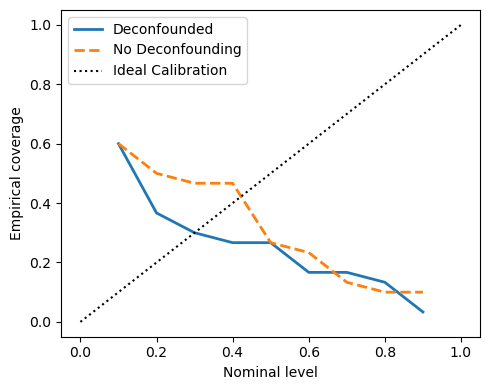

In [63]:
nominal_levels = np.linspace(0.1, 0.9, 9)

emp_cov_ipw = []
emp_cov_no  = []

for level in nominal_levels:
    # IPW model
    q_ipw = np.quantile(residuals_ipw, 1 - level)
    lower = pred_ipw - q_ipw * propensity_test
    upper = pred_ipw + q_ipw * propensity_test
    emp_cov_ipw.append(np.mean((y_test >= lower) & (y_test <= upper)))

    # NO-IPW model
    q_no = np.quantile(residuals_no, 1 - level)
    lower_no = pred_noipw - q_no
    upper_no = pred_noipw + q_no
    emp_cov_no.append(np.mean((y_test >= lower_no) & (y_test <= upper_no)))

# Plot
plt.figure(figsize=(5,4))
plt.plot(nominal_levels, emp_cov_ipw, linewidth=2, label="Deconfounded")
plt.plot(nominal_levels, emp_cov_no, '--', linewidth=2, label="No Deconfounding")
plt.plot([0,1],[0,1],'k:', label="Ideal Calibration")
plt.xlabel("Nominal level")
plt.ylabel("Empirical coverage")
plt.legend()
plt.tight_layout()
# plt.savefig("calibration_plot.pdf")
plt.show()


## Conformal Prediction (Calibration of Prediction Intervals)

In [64]:
from sklearn.model_selection import train_test_split

# Calibration split
X_train0, X_cal, y_train0, y_cal = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42)

# Compute calibrated residuals
with torch.no_grad():
    preds_cal = model_ipw(torch.tensor(X_cal, dtype=torch.float32)).numpy().flatten()

cal_resid = np.abs(y_cal - preds_cal)

alpha = 0.1  # 90% confidence
qhat = np.quantile(cal_resid, 1 - alpha)

print("Calibration band =", qhat)


Calibration band = 7.423997497558596


## Final Predictions With Confidence Intervals

In [65]:
with torch.no_grad():
    preds_test = model_ipw(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()

lower = preds_test - qhat
upper = preds_test + qhat

output_df = pd.DataFrame({
    "True": y_test,
    "Predicted": preds_test,
    "Lower (90%)": lower,
    "Upper (90%)": upper
})

# output_df.head(10)
output_df


,True,Predicted,Lower (90%),Upper (90%)
0,98,95.086685,87.662689,102.510681
1,90,93.348343,85.924347,100.772339
2,72,73.935776,66.511780,81.359772
3,76,75.128952,67.704956,82.552948
4,100,104.149063,96.725067,111.573059
5,68,67.803047,60.379051,75.227043
6,84,85.208054,77.784058,92.632050
7,92,94.440475,87.016479,101.864471
8,82,78.896332,71.472336,86.320328
9,63,65.496063,58.072067,72.920059


## Standard Conformal Residuals

In [66]:
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import matplotlib.pyplot as plt

# 15% calibration split
X_train0, X_cal, y_train0, y_cal = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42)

X_cal_t = torch.tensor(X_cal, dtype=torch.float32)
with torch.no_grad():
    preds_cal = model_noipw(X_cal_t).numpy().flatten()

cal_resid = np.abs(y_cal - preds_cal)
alpha = 0.1  # 90% interval
qhat_std = np.quantile(cal_resid, 1 - alpha)
print("qhat_std (standard conformal):", qhat_std)

# Test predictions
with torch.no_grad():
    preds_test_std = model_noipw(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()

lower_std = preds_test_std - qhat_std
upper_std = preds_test_std + qhat_std


qhat_std (standard conformal): 7.620956420898442


## Figure — Standard Conformal Prediction Intervals

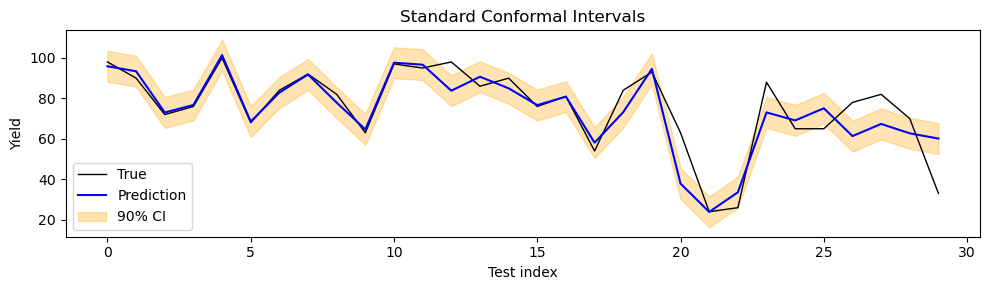

In [68]:
plt.figure(figsize=(10,3))
x = np.arange(len(y_test))

plt.plot(x, y_test, 'k-', label="True", linewidth=1)
plt.plot(x, preds_test_std, 'b-', label="Prediction")
plt.fill_between(x, lower_std, upper_std, color='orange', alpha=0.3, label="90% CI")

plt.xlabel("Test index")
plt.ylabel("Yield")
plt.title("Standard Conformal Intervals")
plt.legend()
plt.tight_layout()
# plt.savefig("standard_conformal_intervals.pdf")
plt.show()


## R2 and MAE of 5 models in 1 plot

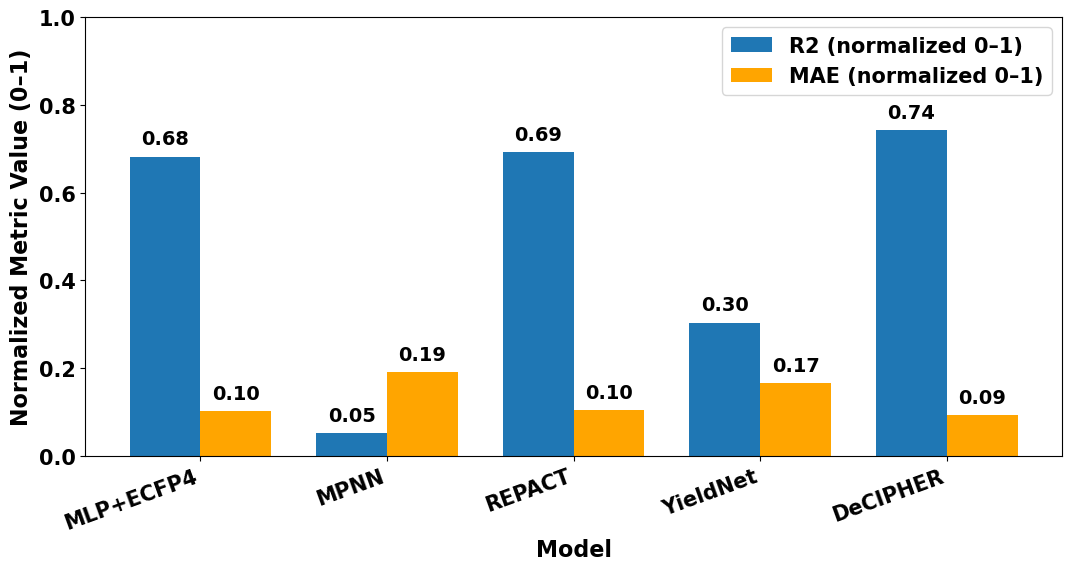

In [138]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Global font configuration
# -----------------------------
FONT_SIZE = 16          # base font size for most text
TITLE_SIZE = 18         # title
LABEL_SIZE = 17         # axis labels
TICK_SIZE  = 15         # tick labels
LEGEND_SIZE = 15        # legend
ANNOT_SIZE = 14         # values on bars

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "font.weight": "bold"
})

# -----------------------------
# Data (fixed order)
# -----------------------------
models = ["MLP+ECFP4", "MPNN", "REPACT", "YieldNet", "DeCIPHER"]

r2 = np.array([
    0.6814756937962926,   # MLP+ECFP4
    0.05269932247251918,  # MPNN
    0.6913674267955847,   # REPACT
    0.30354058969836295,  # YieldNet
    0.7423918173931059    # DeCIPHER
])

mae = np.array([
    0.10272184960756511,  # MLP+ECFP4
    0.19127913648768322,  # MPNN
    0.10374627542800832,  # REPACT
    0.1659703051136153,   # YieldNet
    0.09293967872253504   # DeCIPHER
])

# -----------------------------
# One plot: grouped bars + value labels (2 decimals)
# -----------------------------
x = np.arange(len(models))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

bars_r2  = ax.bar(x - w/2, r2,  width=w, label="R2 (normalized 0–1)")
bars_mae = ax.bar(x + w/2, mae, width=w, label="MAE (normalized 0–1)",color="orange")

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
# ax.set_xticklabels(models)
ax.set_xlabel("Model")
ax.set_ylabel("Normalized Metric Value (0–1)")
# ax.set_title("Normalized R2 and MAE Across Models")
ax.set_ylim(0, 1.0)

ax.legend(loc="best", frameon=True)

# Add numeric labels (2 decimal places) on top of each bar
def add_labels(bars, fontsize=ANNOT_SIZE):
    for b in bars:
        h = b.get_height()
        ax.annotate(
            f"{h:.2f}",
            xy=(b.get_x() + b.get_width() / 2, h),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize
        )

add_labels(bars_r2)
add_labels(bars_mae)

fig.tight_layout()

# Save as PDF
# fig.savefig("r2_mae_all_models_largefont_annoted.pdf", format="pdf", bbox_inches="tight", dpi=400)

plt.show()


## Ablation study plot

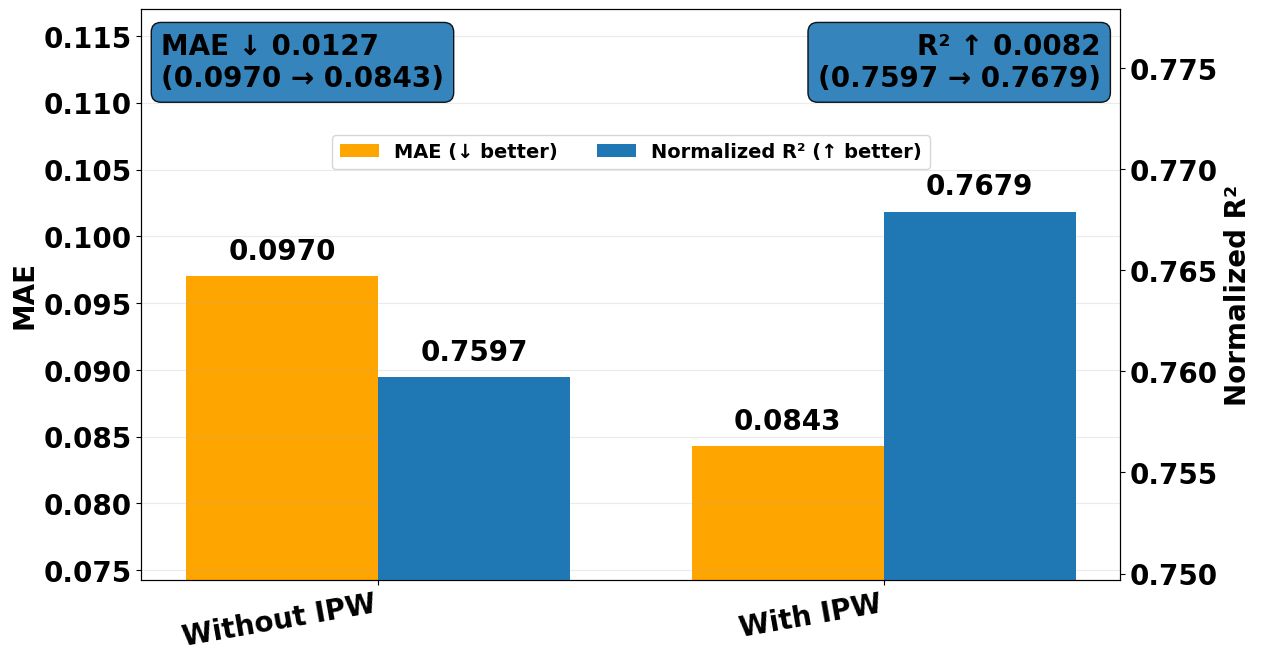

In [135]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Ablation data
# -----------------------------
settings = ["Without IPW", "With IPW"]
mae = np.array([0.0970, 0.0843])
r2  = np.array([0.7597, 0.7679])  # normalized R2 (0–1)

# Improvements
mae_drop = float(mae[0] - mae[1])
r2_gain  = float(r2[1] - r2[0])

# -----------------------------
# Larger fonts (global)
# -----------------------------
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 14,
    "font.weight": "bold"
})

# -----------------------------
# Single plot with two y-axes
# -----------------------------
fig, ax1 = plt.subplots(figsize=(12.5, 6.5), constrained_layout=True)
x = np.arange(len(settings))
w = 0.38
# w = 0.2

# Left axis: MAE bars
bars_mae = ax1.bar(x - w/2, mae, width=w, label="MAE (↓ better)", color="orange")
ax1.set_ylabel("MAE")
ax1.set_xticks(x)
ax1.set_xticklabels(settings, rotation=10, ha="right")

# Right axis: R2 bars
ax2 = ax1.twinx()
bars_r2 = ax2.bar(x + w/2, r2, width=w, label="Normalized R² (↑ better)")
ax2.set_ylabel("Normalized R²")

# Title
# ax1.set_title("Ablation Study: Effect of IPW on MAE and Model Fit")

# y-limits with padding
ax1.set_ylim(mae.min() - 0.01, mae.max() + 0.02)
ax2.set_ylim(r2.min() - 0.01, r2.max() + 0.01)

# Grid
ax1.grid(axis="y", alpha=0.25)

# -----------------------------
# Annotate bar values
# -----------------------------
def annotate_bars(ax, bars, fmt="{:.4f}", dy=8):
    for b in bars:
        h = float(b.get_height())
        ax.annotate(fmt.format(h),
                    (b.get_x() + b.get_width()/2, h),
                    xytext=(0, dy),
                    textcoords="offset points",
                    ha="center", va="bottom")

annotate_bars(ax1, bars_mae, fmt="{:.4f}")
annotate_bars(ax2, bars_r2, fmt="{:.4f}")

# -----------------------------
# Improvement callouts (kept INSIDE the plot box)
# Using axes-fraction coordinates guarantees they remain within boundaries.
# -----------------------------
ax1.text(
    0.02, 0.96,
    f"MAE ↓ {mae_drop:.4f}\n({mae[0]:.4f} → {mae[1]:.4f})",
    transform=ax1.transAxes,
    ha="left", va="top",
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.9)
)

ax1.text(
    0.98, 0.96,
    f"R² ↑ {r2_gain:.4f}\n({r2[0]:.4f} → {r2[1]:.4f})",
    transform=ax1.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.35", alpha=0.9)
)

# -----------------------------
# Combined legend
# -----------------------------
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc="center", bbox_to_anchor=(0.5, 0.75), ncol=2, frameon=True)

# -----------------------------
# Save (PDF)
# -----------------------------
# plt.savefig("ablation_ipw_mae_r2_singleplot.pdf", format="pdf", bbox_inches="tight")
# plt.show()
